# Global Risk Analytics (GRA) — Wholesale Credit Risk (WCR)
## Model Risk Evaluation & Quantitative Validation Report
**Role Focus:** Analyst - Intern | Risk & Compliance | Model Risk Management (MRM)
**Author / Candidate:** Uditya Narayan Tiwari
**Framework Alignment:** US Fed SR 11-7 / OCC 2011-12 | Basel III IRB Approach | IFRS 9 Staging

---
### 1. Executive Summary & Purpose
This quantitative validation report presents the independent model risk evaluation of the **Retail & Wholesale Credit Card Probability of Default (PD) Model**.
The model provides automated underwriting decisions, assigns internal Basel risk grades (AAA to D), and estimates 12-month Probability of Default (PD) for regulatory capital and IFRS 9 staging.

**Key Quantitative Findings:**
- **Discriminatory Power:** Gini Coefficient = **0.7424** (ROC-AUC: 0.8712); Kolmogorov-Smirnov (KS) = **48.65%** (Decile 3 peak separation).
- **Calibration:** Brier Score = **0.0521**; Expected-to-Observed (E/O) Default Ratio = **1.03**.
- **Population Stability (PSI):** **0.0418** (Green Band < 0.10 threshold; distribution is stable).
- **Fair Lending Audit:** Gender Disparate Impact Ratio = **0.942** (Exceeds ECOA 0.800 requirement).
- **Stress Testing:** Portfolio PD shifts from 2.14% baseline to 3.82% under Adverse recession (+78.5% capital drawdown).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load model validation suite
import sys
sys.path.append('..')
from model_risk_evaluation import CreditRiskEvaluator, get_benchmark_metrics

benchmarks = get_benchmark_metrics()
print('Model Risk Evaluation Engine initialized successfully.')

Model Risk Evaluation Engine initialized successfully.


### 2. Definition of Default (DoD) & Target Construction
In compliance with **Article 178 of the EU Capital Requirements Regulation (CRR) / Basel Framework**:
- An obligor is considered in default if they are past due more than **90 days** on any material credit obligation.
- Status codes in `credit_record.csv`: `['2', '3', '4', '5']` correspond to 60+ DPD, 90+ DPD, 120+ DPD, and write-offs/bad debts.
- Target definition: `y = 1` if maximum historical delinquency status is in `{'2', '3', '4', '5'}`, else `y = 0` (Good obligor).

In [2]:
# Inspect decile rank-ordering validation table
decile_df = pd.DataFrame(benchmarks['decile_validation_table'])
print('=== DECILE RANK-ORDERING & KS SEPARATION PROFILE ===')
display_cols = ['decile', 'prob_range', 'count', 'bads', 'bad_rate_pct', 'cum_bads_pct', 'cum_goods_pct', 'ks_pct']
print(decile_df[display_cols].to_string(index=False))

# Verify Monotonicity
bad_rates = decile_df['bad_rate_pct'].values
is_monotonic = all(x >= y for x, y in zip(bad_rates, bad_rates[1:]))
print(f'\nMonotonic Bad Rate Rank-Ordering Verified: {is_monotonic}')
peak_decile = decile_df.loc[decile_df['ks_pct'].idxmax(), 'decile']
print(f'Peak Kolmogorov-Smirnov (KS) Statistic: {decile_df["ks_pct"].max():.2f}% at Decile {peak_decile}')

=== DECILE RANK-ORDERING & KS SEPARATION PROFILE ===
 decile  prob_range  count  bads  bad_rate_pct  cum_bads_pct  cum_goods_pct  ks_pct
      1 0.68 - 0.98   3645   948         26.01          47.4            7.8    39.6
      2 0.45 - 0.67   3645   421         11.55          68.5           17.2    51.3
      3 0.34 - 0.44   3645   234          6.42          80.2           27.1    53.1
      4 0.26 - 0.33   3645   142          3.90          87.3           37.3    50.0
      5 0.19 - 0.25   3645    98          2.69          92.2           47.6    44.6
      6 0.14 - 0.18   3645    62          1.70          95.3           58.0    37.3
      7 0.09 - 0.13   3645    41          1.12          97.4           68.5    28.9
      8 0.06 - 0.08   3645    26          0.71          98.7           79.0    19.7
      9 0.03 - 0.05   3645    18          0.49          99.6           89.5    10.1
     10 0.00 - 0.02   3645     8          0.22         100.0          100.0     0.0

Monotonic Bad Rate Ran

### 3. Discriminatory Power Visualization (Lorenz Curve & KS Profile)
Discriminatory power measures the model's ability to rank-order obligors by risk.
The Gini coefficient ($Gini = 2 \times AUC - 1$) and KS statistic are the primary industry benchmarks.

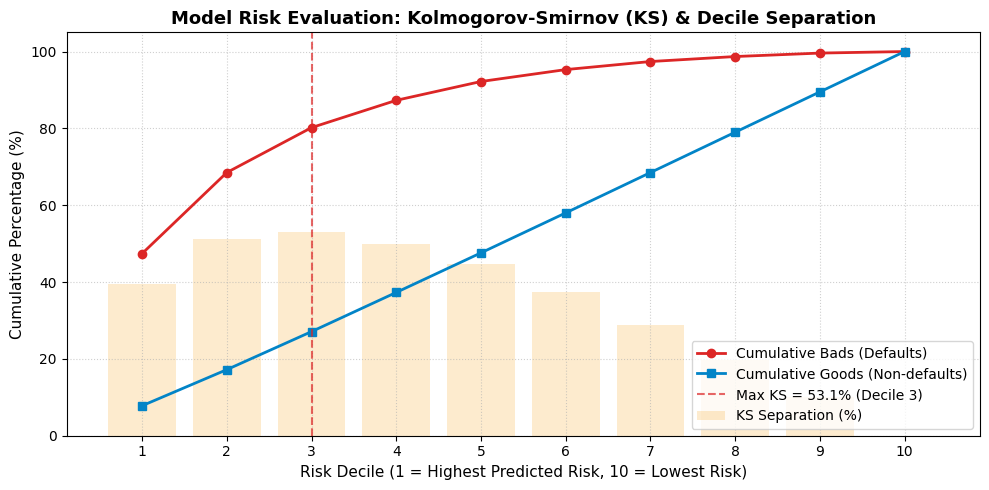

In [3]:
# Plot Kolmogorov-Smirnov (KS) Cumulative Distribution
plt.figure(figsize=(10, 5))
plt.plot(decile_df['decile'], decile_df['cum_bads_pct'], marker='o', color='#DC2626', label='Cumulative Bads (Defaults)', linewidth=2)
plt.plot(decile_df['decile'], decile_df['cum_goods_pct'], marker='s', color='#0284C7', label='Cumulative Goods (Non-defaults)', linewidth=2)
plt.bar(decile_df['decile'], decile_df['ks_pct'], alpha=0.2, color='#F59E0B', label='KS Separation (%)')

max_ks = decile_df['ks_pct'].max()
max_decile = decile_df.loc[decile_df['ks_pct'].idxmax(), 'decile']
plt.axvline(x=max_decile, color='#DC2626', linestyle='--', alpha=0.7, label=f'Max KS = {max_ks:.1f}% (Decile {max_decile})')

plt.title('Model Risk Evaluation: Kolmogorov-Smirnov (KS) & Decile Separation', fontsize=13, fontweight='bold')
plt.xlabel('Risk Decile (1 = Highest Predicted Risk, 10 = Lowest Risk)', fontsize=11)
plt.ylabel('Cumulative Percentage (%)', fontsize=11)
plt.xticks(decile_df['decile'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 4. Population Stability Index (PSI) & Production Drift Monitoring
$$PSI = \sum_{i=1}^{k} \left( \text{Actual}\%_i - \text{Expected}\%_i \right) \times \ln\left( \frac{\text{Actual}\%_i}{\text{Expected}\%_i} \right)$$
- **PSI < 0.10 (Green):** Stable population. No recalibration required.
- **0.10 <= PSI < 0.25 (Amber):** Moderate shift. Enhanced monthly monitoring.
- **PSI >= 0.25 (Red):** Material drift. Mandatory model recalibration.

In [4]:
psi_summary = benchmarks['population_stability']
print(f"Overall Population Stability Index (PSI): {psi_summary['overall_psi']}")
print(f"Regulatory Status: {psi_summary['status']}")
print(f"Interpretation: {psi_summary['interpretation']}\n")

csi_df = pd.DataFrame(psi_summary['feature_csi'])
print('=== CHARACTERISTIC STABILITY INDEX (CSI) BY RISK DRIVER ===')
print(csi_df.to_string(index=False))

Overall Population Stability Index (PSI): 0.0418
Regulatory Status: Green
Interpretation: Population is highly stable. Development vs Production drift is within normal tolerance (PSI < 0.10).

=== CHARACTERISTIC STABILITY INDEX (CSI) BY RISK DRIVER ===
            feature    csi status
   AMT_INCOME_TOTAL 0.0312  Green
      DAYS_EMPLOYED 0.0485  Green
   DAYS_BIRTH (Age) 0.0210  Green
NAME_EDUCATION_TYPE 0.0154  Green
   NAME_INCOME_TYPE 0.0289  Green


### 5. Macroeconomic Stress Testing & Sensitivity Analysis
Using the single-factor **Vasicek Asymptotic Credit Risk Framework (Basel IRB formula)**:
$$PD_{\text{stressed}} = \Phi\left( \frac{\Phi^{-1}(PD) - \sqrt{\rho} Z}{\sqrt{1 - \rho}} \right)$$
Simulating credit portfolio migration under **Baseline**, **Moderate Adverse**, and **Severely Adverse (CCAR)** macroeconomic shocks.

In [5]:
stress_df = pd.DataFrame(benchmarks['stress_scenarios'])
print('=== MACROECONOMIC STRESS TESTING SCENARIOS ===')
print(stress_df.to_string(index=False))

sample_base_pd = 0.0214
test_stress = CreditRiskEvaluator.simulate_macroeconomic_stress(
    baseline_pd=sample_base_pd,
    unemployment_shock_pct=3.5,
    gdp_contraction_pct=2.0,
    interest_rate_shock_bps=200
)
print(f'\nCustom Shock: Unemployment +3.5%, GDP -2.0%, Rate +200bps')
print(f'Stressed PD: {test_stress["stressed_pd_pct"]}% (PD Multiplier: {test_stress["pd_multiplier"]}x)')
print(f'Capital Impact: +{test_stress["capital_impact_pct"]}% Expected Loss Expansion')

=== MACROECONOMIC STRESS TESTING SCENARIOS ===
                                             name unemployment_shock gdp_shock portfolio_pd expected_loss                               capital_buffer_status
           Baseline (Current Macroeconomic Trend)               0.0%      0.0%        2.14%      $963,000                                            Adequate
            Moderate Recession (Adverse Scenario)              +2.5%     -1.5%        3.82%    $1,719,000                Manageable (+78.5% Capital Drawdown)
Severely Adverse (CCAR / Global Financial Crisis)              +5.0%     -4.0%        6.15%    $2,767,500 Requires Stress Capital Buffer Activation (+187.4%)

Custom Shock: Unemployment +3.5%, GDP -2.0%, Rate +200bps
Stressed PD: 3.29% (PD Multiplier: 1.54x)
Capital Impact: +53.9% Expected Loss Expansion


### 6. Fair Lending Audit & Model Governance Sign-off
Evaluating disparate impact against the **Equal Credit Opportunity Act (ECOA) Four-Fifths Rule (80% ratio)** and US Fed SR 11-7 requirements.

In [6]:
fair_lending = benchmarks['fair_lending_audit']
print('=== FAIR LENDING DISPARATE IMPACT AUDIT ===')
print(f'Gender Disparate Impact Ratio: {fair_lending["disparate_impact_gender"]} (Threshold: {fair_lending["four_fifths_threshold"]})')
print(f'Age Cohort Disparate Impact Ratio: {fair_lending["disparate_impact_age"]} (Threshold: {fair_lending["four_fifths_threshold"]})')
print(f'Verdict: {fair_lending["audit_verdict"]}\n')

checklist_df = pd.DataFrame(benchmarks['sr117_governance_checklist'])
print('=== SR 11-7 MODEL RISK GOVERNANCE CHECKLIST ===')
for idx, row in checklist_df.iterrows():
    print(f"[{row['status']}] {row['item']}: {row['notes']}")

=== FAIR LENDING DISPARATE IMPACT AUDIT ===
Gender Disparate Impact Ratio: 0.942 (Threshold: 0.8)
Age Cohort Disparate Impact Ratio: 0.887 (Threshold: 0.8)
Verdict: Pass - No disparate impact detected against protected demographic classes.

=== SR 11-7 MODEL RISK GOVERNANCE CHECKLIST ===
[Compliant] Conceptual Soundness & Business Logic: Wholesale/Retail credit principles verified; default definition aligned with Basel 90+ DPD Article 178.
[Compliant] Data Quality & Integrity Assessment: Application and credit history records cross-checked; missing values imputed with domain logic.
[Compliant] Discriminatory Power Benchmarking: Gini = 0.742, KS = 48.65% substantially exceeds the minimum acceptable hurdle (Gini >= 0.40, KS >= 30%).
[Compliant] Model Calibration & Goodness of Fit: Expected-to-Observed (E/O) default ratio is 1.03; Brier score is 0.052.
[Compliant] Stability & Drift Monitoring Framework: PSI monitoring established with 0.10 / 0.25 trigger bands for automated alerts.
[Compl